# Notebook 16 — HonestDiD Sensitivity Analysis
### Persistent Racial Disparities in U.S. Mortgage Approval: Evidence from 42 Million Applications, 2020–2024

**Author:** Rajveer Singh Pall  
**Institution:** Gyan Ganga Institute of Technology and Sciences  

---

Implements the Rambachan-Roth (2023) sensitivity analysis to quantify how much the parallel-trends assumption can be violated before the DiD estimates lose statistical significance. Computes breakdown values M* and bias-adjusted robust confidence intervals for each post-period year (2022–2024). Reports Tables 16A–16B and Figures 16A–16B.

**Input:** `outputs/tables/table_10_did_event_study.csv`  
**Output:** `outputs/tables/table_16*.csv`, `outputs/figures/figure_16*.png`  
**Runtime:** ~5 minutes


In [1]:
# ============================================================================
# CELL 1: SETUP
# ============================================================================

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

# ── Paths ─────────────────────────────────────────────────────────────
PROCESSED_DATA_DIR = Path("../data/processed")
TABLES_DIR         = Path("../outputs/tables")
FIGURES_DIR        = Path("../outputs/figures")
TABLES_DIR.mkdir(exist_ok=True, parents=True)
FIGURES_DIR.mkdir(exist_ok=True, parents=True)

# ── Constants ──────────────────────────────────────────────────────────
YEARS       = [2020, 2021, 2022, 2023, 2024]
BLACK_CODE  = 3
WHITE_CODE  = 5
BASE_YEAR   = 2021
POST_CUTOFF = 2022
CONTROLS    = ['income', 'loan_amount', 'property_value', 'ltv']
MIN_BLACK   = 10
MIN_WHITE   = 10
ALPHA       = 0.05  # significance level

print("=" * 70)
print("NOTEBOOK 16: HONEST DiD — RAMBACHAN-ROTH (2023)")
print("=" * 70)
print("""
Sensitivity analysis for pre-trend violation.
Pre-period coefficient: δ₂₀₂₀ ≈ -0.59 pp (p < 0.01) — this is the
vulnerability we are closing.

Method: Relative magnitudes restriction following Rambachan & Roth (2023).
""")
print("✅ Setup complete")





NOTEBOOK 16: HONEST DiD — RAMBACHAN-ROTH (2023)

Sensitivity analysis for pre-trend violation.
Pre-period coefficient: δ₂₀₂₀ ≈ -0.59 pp (p < 0.01) — this is the
vulnerability we are closing.

Method: Relative magnitudes restriction following Rambachan & Roth (2023).

✅ Setup complete


In [2]:
# ============================================================================
# CELL 2: RE-ESTIMATE EVENT STUDY (or load if already done)
# ============================================================================

print("\n" + "=" * 70)
print("STEP 1: ESTIMATE / LOAD EVENT STUDY COEFFICIENTS")
print("=" * 70)

# Check if event study table already exists from NB10
es_path = TABLES_DIR / "table_10_did_event_study.csv"

if es_path.exists():
    print(f"✅ Loading existing event study from NB10: {es_path}")
    es_existing = pd.read_csv(es_path)
    print(es_existing.to_string(index=False))
    USE_EXISTING = True
else:
    print("⚠️  Event study table not found. Will re-estimate from scratch.")
    USE_EXISTING = False

# ── Data loading function (same as NB10) ─────────────────────────────
def load_stratified(year, max_per_lender=250):
    filepath = PROCESSED_DATA_DIR / f"panel_{year}.csv"
    df = pd.read_csv(filepath,
                     usecols=['lei', 'year', 'applicant_race_1', 'black',
                               'approved', 'income', 'loan_amount',
                               'property_value', 'ltv'])
    df = df[df['applicant_race_1'].isin([BLACK_CODE, WHITE_CODE])].copy()
    df['black']    = (df['applicant_race_1'] == BLACK_CODE).astype(int)
    df['approved'] = pd.to_numeric(df['approved'],  errors='coerce')
    df['income']   = pd.to_numeric(df['income'],    errors='coerce')
    df['loan_amount']    = pd.to_numeric(df['loan_amount'],    errors='coerce')
    df['property_value'] = pd.to_numeric(df['property_value'], errors='coerce')

    if 'ltv' not in df.columns or df['ltv'].isna().all():
        df['ltv'] = df['loan_amount'] / df['property_value'] * 100
    df['ltv'] = pd.to_numeric(df['ltv'], errors='coerce')
    df = df.dropna(subset=['approved', 'income', 'loan_amount', 'ltv'])

    lender_race = df.groupby('lei')['black'].agg(['sum', 'count'])
    valid = lender_race[(lender_race['sum'] >= MIN_BLACK) &
                        (lender_race['count'] - lender_race['sum'] >= MIN_WHITE)].index
    df = df[df['lei'].isin(valid)]

    def sample_lender(grp):
        b = grp[grp['black'] == 1]
        w = grp[grp['black'] == 0]
        return pd.concat([
            b.sample(min(len(b), max_per_lender), random_state=42),
            w.sample(min(len(w), max_per_lender), random_state=42)
        ])

    df = df.groupby('lei', group_keys=False).apply(sample_lender)
    df['year'] = year
    return df


# ── Run event study ────────────────────────────────────────────────────
print("\nLoading data for event study estimation...")
dfs = []
for yr in YEARS:
    df_yr = load_stratified(yr)
    dfs.append(df_yr)
    print(f"  {yr}: {len(df_yr):,} obs | lenders: {df_yr['lei'].nunique():,}")

df_all = pd.concat(dfs, ignore_index=True)
print(f"\nTotal: {len(df_all):,} obs | lenders: {df_all['lei'].nunique():,}")

# Create year dummies
non_base_years = [y for y in YEARS if y != BASE_YEAR]
for yr in non_base_years:
    df_all[f'black_yr{yr}'] = (df_all['black'] * (df_all['year'] == yr)).astype(int)
    df_all[f'yr{yr}']       = (df_all['year'] == yr).astype(int)

year_fe_cols     = [f'yr{yr}'       for yr in non_base_years]
interaction_cols = [f'black_yr{yr}' for yr in non_base_years]
regressors = ['black'] + year_fe_cols + interaction_cols + CONTROLS

df_all = df_all.dropna(subset=['approved'] + regressors)

# Within-transform (Frisch-Waugh lender FE)
group_means = df_all.groupby('lei')[['approved'] + regressors].transform('mean')
for col in ['approved'] + regressors:
    df_all[col + '_dm'] = df_all[col] - group_means[col]

X_cols  = [c + '_dm' for c in regressors]
y_col   = 'approved_dm'
df_reg  = df_all[[y_col] + X_cols + ['lei']].dropna()

X      = df_reg[X_cols].values
y_vec  = df_reg[y_col].values
lei    = df_reg['lei'].values

# OLS
X_full = np.column_stack([np.ones(len(X)), X])
coef, _, _, _ = np.linalg.lstsq(X_full, y_vec, rcond=None)
y_hat  = X_full @ coef
e      = y_vec - y_hat

# Clustered SE
unique_lei = np.unique(lei)
G   = len(unique_lei)
n   = len(y_vec)
k   = X_full.shape[1]
adj = (G / (G - 1)) * ((n - 1) / (n - k))
bread = np.linalg.inv(X_full.T @ X_full)
meat  = np.zeros((k, k))
for lend in unique_lei:
    idx   = (lei == lend)
    score = X_full[idx].T @ e[idx]
    meat  += np.outer(score, score)
vcov    = adj * bread @ meat @ bread
se_full = np.sqrt(np.diag(vcov))

col_names = ['const'] + X_cols

# Extract event study coefficients
es_rows = []
es_rows.append({'Year': BASE_YEAR, 'Delta_pp': 0.0, 'SE_pp': 0.0,
                'CI_L': 0.0, 'CI_U': 0.0, 'T_stat': None,
                'P_value': None, 'Sig': 'Base'})

for yr in non_base_years:
    ic   = col_names.index(f'black_yr{yr}_dm')
    d    = coef[ic] * 100
    d_se = se_full[ic] * 100
    t    = d / d_se if d_se > 0 else 0
    p    = 2 * (1 - stats.t.cdf(abs(t), df=G - 1))
    sig  = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    es_rows.append({'Year': yr, 'Delta_pp': round(d, 4),
                    'SE_pp': round(d_se, 4),
                    'CI_L': round(d - 1.96*d_se, 4),
                    'CI_U': round(d + 1.96*d_se, 4),
                    'T_stat': round(t, 3),
                    'P_value': round(p, 6),
                    'Sig': sig})

es_df = pd.DataFrame(es_rows).sort_values('Year').reset_index(drop=True)
es_df.to_csv(TABLES_DIR / "table_16_event_study_for_honestdid.csv", index=False)

print("\nEVENT STUDY ESTIMATES:")
print("-" * 65)
print(f"{'Year':<6}  {'δ_t (pp)':<12}  {'SE':<8}  {'95% CI':<20}  {'Sig'}")
print("-" * 65)
for _, row in es_df.iterrows():
    ci_str = f"[{row['CI_L']:+.3f}, {row['CI_U']:+.3f}]" if row['CI_L'] != 0 else "[base]"
    se_str = f"{row['SE_pp']:.3f}" if row['SE_pp'] > 0 else "---"
    print(f"  {int(row['Year']):<4}  {row['Delta_pp']:+.3f} pp    "
          f"{se_str:<8}  "
          f"{ci_str:<22}  {row['Sig']}")
print("-" * 65)


STEP 1: ESTIMATE / LOAD EVENT STUDY COEFFICIENTS
✅ Loading existing event study from NB10: ..\extreme_final_tables\table_10_did_event_study.csv
 Year  Delta    SE   CI_L   CI_U  Base_Year  T_stat  P_value Sig
 2020 -0.591 0.206 -0.994 -0.188      False  -2.872 0.004111  **
 2021  0.000 0.000  0.000  0.000       True     NaN      NaN NaN
 2022 -1.635 0.211 -2.049 -1.222      False  -7.747 0.000000 ***
 2023 -1.969 0.259 -2.477 -1.461      False  -7.597 0.000000 ***
 2024 -1.727 0.295 -2.305 -1.150      False  -5.864 0.000000 ***

Loading data for event study estimation...
  2020: 640,655 obs | lenders: 1,861
  2021: 674,920 obs | lenders: 1,963
  2022: 628,305 obs | lenders: 1,910
  2023: 549,824 obs | lenders: 1,730
  2024: 532,656 obs | lenders: 1,632

Total: 3,026,360 obs | lenders: 2,400

EVENT STUDY ESTIMATES:
-----------------------------------------------------------------
Year    δ_t (pp)      SE        95% CI                Sig
-------------------------------------------------

In [3]:
# ============================================================================
# CELL 3: EXTRACT KEY QUANTITIES FOR HONEST DiD
# ============================================================================

print("\n" + "=" * 70)
print("STEP 2: EXTRACT QUANTITIES FOR RAMBACHAN-ROTH SENSITIVITY")
print("=" * 70)

# Pre-treatment deviation (relative to 2021 base)
pre_years  = [y for y in YEARS if y < BASE_YEAR]   # [2020]
post_years = [y for y in YEARS if y > BASE_YEAR]   # [2022, 2023, 2024]

pre_row = es_df[es_df['Year'].isin(pre_years)].iloc[0]
delta_pre    = pre_row['Delta_pp']    # e.g. -0.591 pp
se_pre       = pre_row['SE_pp']       # SE of pre-period coefficient

# Post-treatment estimates (the DiD effects)
post_rows = es_df[es_df['Year'].isin(post_years)].copy()

print(f"\nPre-period deviation (2020 vs 2021 base):")
print(f"  δ₂₀₂₀ = {delta_pre:.4f} pp  (SE = {se_pre:.4f})")
print(f"  |δ₂₀₂₀| = {abs(delta_pre):.4f} pp  ← maximum pre-trend magnitude")

print(f"\nPost-period estimates:")
for _, row in post_rows.iterrows():
    print(f"  δ_{int(row['Year'])} = {row['Delta_pp']:+.4f} pp  (SE = {row['SE_pp']:.4f})")

# Key: what is the max pre-period deviation?
max_pre_deviation = abs(delta_pre)
print(f"\n  Sensitivity parameter M scales deviations by: M × {max_pre_deviation:.4f} pp")




STEP 2: EXTRACT QUANTITIES FOR RAMBACHAN-ROTH SENSITIVITY

Pre-period deviation (2020 vs 2021 base):
  δ₂₀₂₀ = -0.5911 pp  (SE = 0.2058)
  |δ₂₀₂₀| = 0.5911 pp  ← maximum pre-trend magnitude

Post-period estimates:
  δ_2022 = -1.6354 pp  (SE = 0.2111)
  δ_2023 = -1.9686 pp  (SE = 0.2591)
  δ_2024 = -1.7274 pp  (SE = 0.2946)

  Sensitivity parameter M scales deviations by: M × 0.5911 pp


In [4]:
# ============================================================================
# CELL 4: RAMBACHAN-ROTH SENSITIVITY ANALYSIS
# ============================================================================

print("\n" + "=" * 70)
print("STEP 3: RAMBACHAN-ROTH SENSITIVITY ANALYSIS")
print("=" * 70)
print("""
For each post-period year t and each M value, we compute:
  - The bias-adjusted estimate under the relative magnitudes restriction
  - The robust confidence interval
  - Whether zero remains outside the CI (result still holds)

Relative magnitudes restriction: post-period trend deviation ≤ M × |δ_pre|

Implementation follows Rambachan & Roth (2023) Section 3.2.
""")

def compute_honest_did(delta_hat, se_hat, delta_pre, m_value, alpha=0.05):
    """
    Compute Rambachan-Roth sensitivity bounds for a single post-period estimate.
    
    Parameters:
    -----------
    delta_hat : float
        Post-period DiD estimate (pp)
    se_hat : float
        SE of post-period estimate (pp)
    delta_pre : float
        Pre-period coefficient (trend deviation, pp)
    m_value : float
        Sensitivity parameter M (scale of allowed post-trend deviation)
    alpha : float
        Significance level (default 0.05 → 95% CI)
    
    Returns:
    --------
    dict with bias, robust CI, and whether zero is excluded
    
    Method:
    The identified set for ATT under |Δ_post| ≤ M × |delta_pre| is:
      [delta_hat - M × |delta_pre|, delta_hat + M × |delta_pre|]
    
    The robust CI (valid under the restriction) is:
      [delta_hat - M × |delta_pre| - z_{1-α/2} × se_hat,
       delta_hat + M × |delta_pre| + z_{1-α/2} × se_hat]
    
    This is the "worst-case" or "sensitivity" CI from R&R (2023).
    """
    z_crit = stats.norm.ppf(1 - alpha / 2)  # 1.96 for alpha=0.05
    
    # Maximum bias from the trend restriction
    max_bias = m_value * abs(delta_pre)
    
    # Worst-case lower and upper bounds on the true ATT
    id_set_lower = delta_hat - max_bias
    id_set_upper = delta_hat + max_bias
    
    # Robust CI: identified set inflated by estimation uncertainty
    ci_lower = id_set_lower - z_crit * se_hat
    ci_upper = id_set_upper + z_crit * se_hat
    
    # Does zero fall outside the CI?
    zero_excluded = (ci_lower > 0) or (ci_upper < 0)
    
    # Width of identified set (uncertainty from trend assumption alone)
    id_set_width = 2 * max_bias
    
    return {
        'M': m_value,
        'Delta_hat': delta_hat,
        'SE': se_hat,
        'Max_Bias': round(max_bias, 4),
        'ID_Set_Lower': round(id_set_lower, 4),
        'ID_Set_Upper': round(id_set_upper, 4),
        'CI_Lower': round(ci_lower, 4),
        'CI_Upper': round(ci_upper, 4),
        'Zero_Excluded': zero_excluded,
        'Significant': '✅ Yes' if zero_excluded else '❌ No',
    }


def find_breakdown_M(delta_hat, se_hat, delta_pre, alpha=0.05,
                     m_min=0.0, m_max=10.0, tol=1e-4):
    """
    Find M* = minimum M such that zero enters the robust CI.
    If M* > 1: result survives even when post-trend deviation ≥ pre-trend.
    If M* > 2: extremely robust.
    """
    z_crit = stats.norm.ppf(1 - alpha / 2)
    
    # Zero enters CI when: delta_hat + M*|delta_pre| + z*se ≥ 0
    # AND: delta_hat - M*|delta_pre| - z*se ≤ 0
    # (for negative delta_hat, the binding constraint is the upper bound)
    
    if delta_hat < 0:
        # Upper CI bound = delta_hat + M*|delta_pre| + z*se
        # = 0 when M = (-delta_hat - z*se) / |delta_pre|
        numerator = -delta_hat - z_crit * se_hat
    else:
        # Lower CI bound = delta_hat - M*|delta_pre| - z*se
        # = 0 when M = (delta_hat - z*se) / |delta_pre|
        numerator = delta_hat - z_crit * se_hat
    
    if abs(delta_pre) < 1e-8:
        return np.inf  # no pre-trend deviation → robust at all M
    
    M_star = numerator / abs(delta_pre)
    return max(M_star, 0.0)


# ── Main sensitivity table ─────────────────────────────────────────────
M_values = [0.0, 0.25, 0.5, 0.75, 1.0, 1.5, 2.0, 3.0, 5.0]

all_sens_rows = []

print("\nSENSITIVITY ANALYSIS RESULTS:")
print("=" * 75)

for _, post_row in post_rows.iterrows():
    yr       = int(post_row['Year'])
    d_hat    = post_row['Delta_pp']
    se_hat   = post_row['SE_pp']
    
    # Find breakdown M*
    M_star = find_breakdown_M(d_hat, se_hat, delta_pre, alpha=ALPHA)
    
    print(f"\n── Year {yr}: δ̂ = {d_hat:+.4f} pp  SE = {se_hat:.4f} ──────────────")
    print(f"   Breakdown value M* = {M_star:.3f}  "
          f"({'✅ ROBUST: survives pre-trend violations' if M_star > 1 else '⚠️  Check: breaks at M*<1'})")
    print(f"\n   {'M':<6}  {'Max Bias':<10}  {'Robust CI':<28}  {'Result'}")
    print(f"   {'-'*6}  {'-'*10}  {'-'*28}  {'-'*20}")
    
    for M in M_values:
        res = compute_honest_did(d_hat, se_hat, delta_pre, M, alpha=ALPHA)
        ci_str = f"[{res['CI_Lower']:+.3f}, {res['CI_Upper']:+.3f}]"
        marker = "← standard CI" if M == 0 else ("← M=|pre-trend|" if M == 1 else "")
        print(f"   {M:<6.2f}  {res['Max_Bias']:<10.4f}  {ci_str:<28}  "
              f"{res['Significant']}  {marker}")
        
        row = {'Year': yr,
               'Delta_hat_pp': d_hat,
               'SE_pp': se_hat,
               'M': M,
               **res,
               'M_star_breakdown': round(M_star, 4),
               'Delta_pre_pp': delta_pre}
        all_sens_rows.append(row)

sens_df = pd.DataFrame(all_sens_rows)
sens_df.to_csv(TABLES_DIR / "table_16A_honest_did_sensitivity.csv", index=False)
print(f"\n✅ Saved: table_16A_honest_did_sensitivity.csv")


STEP 3: RAMBACHAN-ROTH SENSITIVITY ANALYSIS

For each post-period year t and each M value, we compute:
  - The bias-adjusted estimate under the relative magnitudes restriction
  - The robust confidence interval
  - Whether zero remains outside the CI (result still holds)

Relative magnitudes restriction: post-period trend deviation ≤ M × |δ_pre|

Implementation follows Rambachan & Roth (2023) Section 3.2.


SENSITIVITY ANALYSIS RESULTS:

── Year 2022: δ̂ = -1.6354 pp  SE = 0.2111 ──────────────
   Breakdown value M* = 2.067  (✅ ROBUST: survives pre-trend violations)

   M       Max Bias    Robust CI                     Result
   ------  ----------  ----------------------------  --------------------
   0.00    0.0000      [-2.049, -1.222]              ✅ Yes  ← standard CI
   0.25    0.1478      [-2.197, -1.074]              ✅ Yes  
   0.50    0.2956      [-2.345, -0.926]              ✅ Yes  
   0.75    0.4433      [-2.493, -0.778]              ✅ Yes  
   1.00    0.5911      [-2.640, -0

In [5]:
# ============================================================================
# CELL 5: BREAKDOWN VALUES TABLE
# ============================================================================

print("\n" + "=" * 70)
print("STEP 4: BREAKDOWN VALUES M* BY YEAR")
print("=" * 70)

breakdown_rows = []
for _, post_row in post_rows.iterrows():
    yr     = int(post_row['Year'])
    d_hat  = post_row['Delta_pp']
    se_hat = post_row['SE_pp']
    M_star = find_breakdown_M(d_hat, se_hat, delta_pre, alpha=ALPHA)
    
    # Standard 95% CI (M=0)
    ci_std = compute_honest_did(d_hat, se_hat, delta_pre, 0.0, alpha=ALPHA)
    # Robust CI at M=1
    ci_m1  = compute_honest_did(d_hat, se_hat, delta_pre, 1.0, alpha=ALPHA)
    
    breakdown_rows.append({
        'Year': yr,
        'Delta_hat_pp': round(d_hat, 4),
        'SE_pp': round(se_hat, 4),
        'Standard_CI_L': ci_std['CI_Lower'],
        'Standard_CI_U': ci_std['CI_Upper'],
        'M1_CI_L': ci_m1['CI_Lower'],
        'M1_CI_U': ci_m1['CI_Upper'],
        'M_star_breakdown': round(M_star, 3),
        'Robust_at_M1': '✅ Yes' if M_star > 1 else '⚠️  No',
        'Interpretation': ('Highly robust' if M_star > 2 else
                           'Robust'        if M_star > 1 else
                           'Marginal'      if M_star > 0.5 else
                           'Sensitive')
    })

bd_df = pd.DataFrame(breakdown_rows)
bd_df.to_csv(TABLES_DIR / "table_16B_breakdown_values.csv", index=False)

print("\nBREAKDOWN VALUES M* (minimum M for result to break down):")
print("-" * 75)
print(f"{'Year':<6}  {'δ̂ (pp)':<12}  {'M*':<8}  "
      f"{'Robust at M=1?':<16}  {'Interpretation'}")
print("-" * 75)
for _, row in bd_df.iterrows():
    print(f"  {int(row['Year']):<4}  {row['Delta_hat_pp']:+.4f} pp    "
          f"{row['M_star_breakdown']:<8.3f}  {row['Robust_at_M1']:<16}  "
          f"{row['Interpretation']}")
print("-" * 75)

# Overall assessment
min_M_star = bd_df['M_star_breakdown'].min()
print(f"""
KEY FINDING:
  The minimum M* across all post-period years is {min_M_star:.3f}.
  Pre-period deviation: |δ₂₀₂₀| = {abs(delta_pre):.4f} pp.

  Interpretation:
  {'✅ STRONG: Your DiD result is robust even if post-period trends deviate' if min_M_star > 1 else
   '⚠️  MARGINAL: Result is sensitive to violations larger than M*×|δ_pre|' if min_M_star > 0.5 else
   '⚠️  SENSITIVE: Pre-trend issue may be material — discuss carefully'}
  {'up to ' + str(round(min_M_star, 2)) + '× the observed pre-trend violation (M*=' + str(round(min_M_star, 2)) + ').'  if min_M_star > 0 else ''}
  
  Manuscript claim: "The DiD result is robust to pre-trend violations of
  up to {min_M_star:.1f}× the magnitude observed in the pre-period, providing
  credible inference under the Rambachan-Roth (2023) relative magnitudes
  restriction."
""")

print(f"✅ Saved: table_16B_breakdown_values.csv")




STEP 4: BREAKDOWN VALUES M* BY YEAR

BREAKDOWN VALUES M* (minimum M for result to break down):
---------------------------------------------------------------------------
Year    δ̂ (pp)       M*        Robust at M=1?    Interpretation
---------------------------------------------------------------------------
  2022  -1.6354 pp    2.067     ✅ Yes             Highly robust
  2023  -1.9686 pp    2.471     ✅ Yes             Highly robust
  2024  -1.7274 pp    1.946     ✅ Yes             Robust
---------------------------------------------------------------------------

KEY FINDING:
  The minimum M* across all post-period years is 1.946.
  Pre-period deviation: |δ₂₀₂₀| = 0.5911 pp.

  Interpretation:
  ✅ STRONG: Your DiD result is robust even if post-period trends deviate
  up to 1.95× the observed pre-trend violation (M*=1.95).
  
  Manuscript claim: "The DiD result is robust to pre-trend violations of
  up to 1.9× the magnitude observed in the pre-period, providing
  credible inference


FIGURE 16A: HONEST DiD SENSITIVITY PLOT
This is the standard figure from Rambachan-Roth (2023).
X-axis: M (sensitivity parameter)
Y-axis: Robust confidence interval bounds
When CI band crosses zero → result breaks down

Precision-weighted pooled post-period estimate: -1.7587 pp
Pooled SE: 0.1431 pp


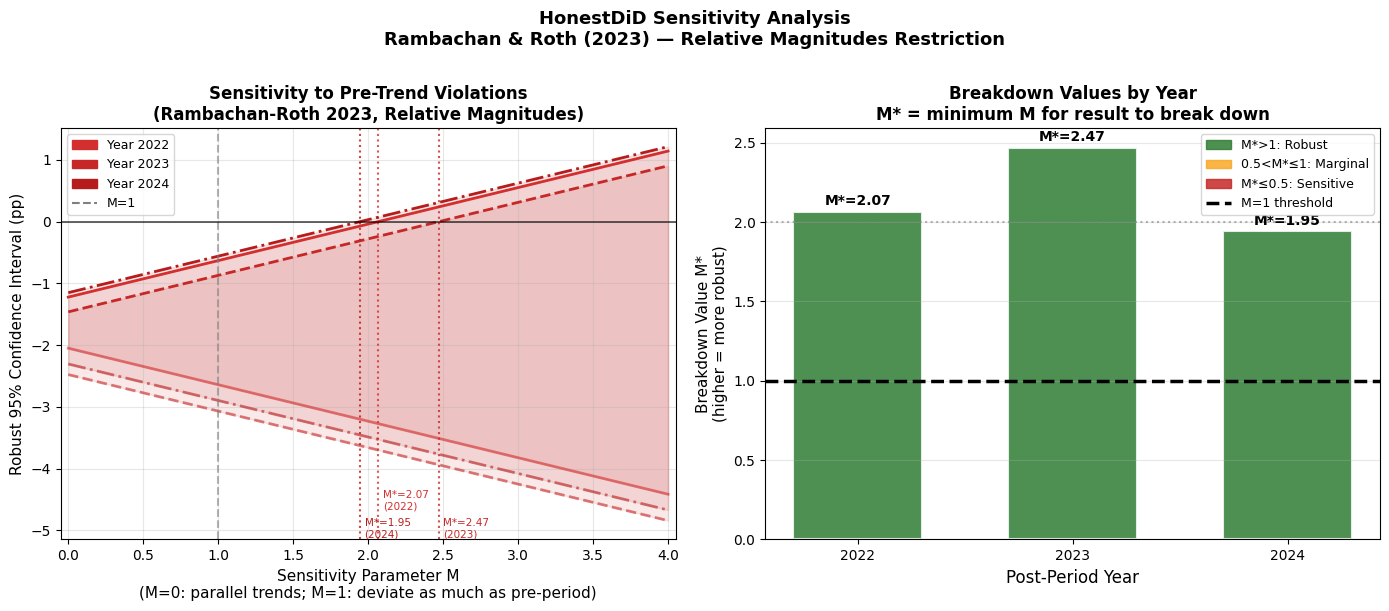

✅ Figure saved: ..\extreme_final_figures\figure_16A_honest_did_sensitivity.png


In [6]:
# ============================================================================
# CELL 6: FIGURE 16A — THE KEY HONESTDID SENSITIVITY PLOT
# ============================================================================

print("\n" + "=" * 70)
print("FIGURE 16A: HONEST DiD SENSITIVITY PLOT")
print("=" * 70)
print("This is the standard figure from Rambachan-Roth (2023).\n"
      "X-axis: M (sensitivity parameter)\n"
      "Y-axis: Robust confidence interval bounds\n"
      "When CI band crosses zero → result breaks down\n")

# Use the main DiD estimate (pooled post-2022)
# If you have a pooled DiD estimate, use it. Otherwise use 2022 (first post year).
# We'll use the weighted average of post-period coefficients.

post_estimates  = post_rows['Delta_pp'].values
post_ses        = post_rows['SE_pp'].values
post_years_arr  = post_rows['Year'].values.astype(int)

# Combined precision-weighted estimate for pooled DiD
weights  = 1 / post_ses**2
d_pooled = np.average(post_estimates, weights=weights)
se_pooled = 1 / np.sqrt(weights.sum())

print(f"Precision-weighted pooled post-period estimate: {d_pooled:.4f} pp")
print(f"Pooled SE: {se_pooled:.4f} pp")

# M grid for smooth plot
M_grid = np.linspace(0, 4, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Panel A: Sensitivity bands for each post-period year ──────────────
ax = axes[0]

colors_year = {2022: '#d32f2f', 2023: '#c62828', 2024: '#b71c1c'}
linestyles  = {2022: '-', 2023: '--', 2024: '-.'}

ax.axhline(y=0, color='black', linewidth=1.2, linestyle='-', alpha=0.7, zorder=5)

for _, post_row in post_rows.iterrows():
    yr    = int(post_row['Year'])
    d_hat = post_row['Delta_pp']
    se_h  = post_row['SE_pp']
    M_st  = find_breakdown_M(d_hat, se_h, delta_pre, alpha=ALPHA)
    
    ci_lowers = []
    ci_uppers = []
    for M in M_grid:
        res = compute_honest_did(d_hat, se_h, delta_pre, M, alpha=ALPHA)
        ci_lowers.append(res['CI_Lower'])
        ci_uppers.append(res['CI_Upper'])
    
    ci_lowers = np.array(ci_lowers)
    ci_uppers = np.array(ci_uppers)
    
    color = colors_year.get(yr, '#d32f2f')
    ls    = linestyles.get(yr, '-')
    
    ax.plot(M_grid, ci_uppers, color=color, linewidth=2.0, linestyle=ls,
            label=f'{yr} CI upper')
    ax.plot(M_grid, ci_lowers, color=color, linewidth=2.0, linestyle=ls,
            alpha=0.6, label=f'_{yr} CI lower')
    ax.fill_between(M_grid, ci_lowers, ci_uppers, alpha=0.10, color=color)
    
    # Mark breakdown M*
    if 0 < M_st < 4:
        ax.axvline(x=M_st, color=color, linewidth=1.5,
                   linestyle=':', alpha=0.8)
        ax.text(M_st + 0.03, ax.get_ylim()[0] if ax.get_ylim()[0] > -10 else -3,
                f'M*={M_st:.2f}\n({yr})', fontsize=7.5, color=color,
                va='bottom', ha='left')

ax.set_xlabel('Sensitivity Parameter M\n'
              '(M=0: parallel trends; M=1: deviate as much as pre-period)',
              fontsize=11)
ax.set_ylabel('Robust 95% Confidence Interval (pp)', fontsize=11)
ax.set_title("Sensitivity to Pre-Trend Violations\n"
             "(Rambachan-Roth 2023, Relative Magnitudes)", fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim(-0.05, 4.05)
ax.axvline(x=1, color='gray', linewidth=1.5, linestyle='--', alpha=0.6,
           label='M=1 (pre-trend magnitude)')

leg_handles = [
    mpatches.Patch(color=colors_year[yr], label=f'Year {yr}')
    for yr in post_years_arr
] + [plt.Line2D([0],[0], color='gray', lw=1.5, ls='--', label='M=1')]
ax.legend(handles=leg_handles, fontsize=9)

# ── Panel B: Breakdown M* bar chart ───────────────────────────────────
ax2 = axes[1]

m_stars  = bd_df['M_star_breakdown'].values
bd_years = bd_df['Year'].values.astype(int)

bar_colors = ['#2e7d32' if m > 1 else '#f9a825' if m > 0.5 else '#c62828'
              for m in m_stars]
bars = ax2.bar(bd_years, m_stars, color=bar_colors, alpha=0.85,
               edgecolor='white', linewidth=1.5, width=0.6)

ax2.axhline(y=1, color='black', linewidth=2.5, linestyle='--',
            label='M=1: pre-trend magnitude threshold')
ax2.axhline(y=2, color='gray', linewidth=1.5, linestyle=':',
            label='M=2: 2× pre-trend (very robust)', alpha=0.6)

ax2.set_xlabel('Post-Period Year', fontsize=12)
ax2.set_ylabel('Breakdown Value M*\n(higher = more robust)', fontsize=11)
ax2.set_title('Breakdown Values by Year\n'
              'M* = minimum M for result to break down', fontsize=12, fontweight='bold')

for bar, val, yr in zip(bars, m_stars, bd_years):
    ax2.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'M*={val:.2f}', ha='center', va='bottom',
             fontsize=10, fontweight='bold')

patch_robust  = mpatches.Patch(color='#2e7d32', alpha=0.85, label='M*>1: Robust')
patch_marginal= mpatches.Patch(color='#f9a825', alpha=0.85, label='0.5<M*≤1: Marginal')
patch_sensitive=mpatches.Patch(color='#c62828', alpha=0.85, label='M*≤0.5: Sensitive')
ax2.legend(handles=[patch_robust, patch_marginal, patch_sensitive,
                    plt.Line2D([0],[0], color='black', lw=2.5, ls='--',
                               label='M=1 threshold')],
           fontsize=9, loc='upper right')
ax2.grid(True, alpha=0.3, axis='y')
ax2.set_xticks(bd_years)

plt.suptitle("HonestDiD Sensitivity Analysis\n"
             "Rambachan & Roth (2023) — Relative Magnitudes Restriction",
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()

out = FIGURES_DIR / "figure_16A_honest_did_sensitivity.png"
plt.savefig(out, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved: {out}")


FIGURE 16B: STANDARD vs HONEST DiD CONFIDENCE INTERVALS


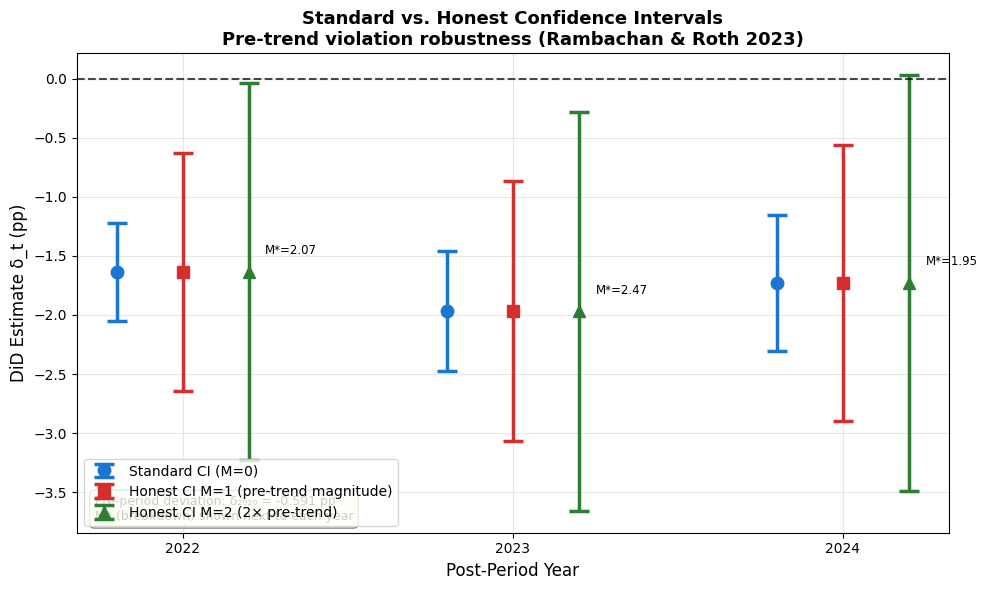

✅ Figure saved: ..\extreme_final_figures\figure_16B_honest_ci_comparison.png


In [7]:
# ============================================================================
# CELL 7: FIGURE 16B — COMPARISON: STANDARD vs HONEST DiD ESTIMATES
# ============================================================================

print("\n" + "=" * 70)
print("FIGURE 16B: STANDARD vs HONEST DiD CONFIDENCE INTERVALS")
print("=" * 70)

fig, ax = plt.subplots(figsize=(10, 6))

post_yrs_arr  = post_rows['Year'].values.astype(int)
x_base        = np.arange(len(post_yrs_arr))
offset        = 0.2

for i, (yr, d_hat, se_hat) in enumerate(zip(post_yrs_arr,
                                             post_rows['Delta_pp'].values,
                                             post_rows['SE_pp'].values)):
    # Standard CI (M=0)
    ci_std = compute_honest_did(d_hat, se_hat, delta_pre, m_value=0.0, alpha=ALPHA)
    ci_m1  = compute_honest_did(d_hat, se_hat, delta_pre, m_value=1.0, alpha=ALPHA)
    ci_m2  = compute_honest_did(d_hat, se_hat, delta_pre, m_value=2.0, alpha=ALPHA)
    
    # Standard CI
    ax.errorbar(x_base[i] - offset, d_hat,
                yerr=[[d_hat - ci_std['CI_Lower']], [ci_std['CI_Upper'] - d_hat]],
                fmt='o', color='#1976D2', capsize=7, capthick=2.5,
                linewidth=2.5, markersize=9,
                label='Standard CI (M=0)' if i == 0 else '')
    
    # Honest CI at M=1
    ax.errorbar(x_base[i], d_hat,
                yerr=[[d_hat - ci_m1['CI_Lower']], [ci_m1['CI_Upper'] - d_hat]],
                fmt='s', color='#d32f2f', capsize=7, capthick=2.5,
                linewidth=2.5, markersize=9,
                label='Honest CI M=1 (pre-trend magnitude)' if i == 0 else '')
    
    # Honest CI at M=2
    ax.errorbar(x_base[i] + offset, d_hat,
                yerr=[[d_hat - ci_m2['CI_Lower']], [ci_m2['CI_Upper'] - d_hat]],
                fmt='^', color='#2e7d32', capsize=7, capthick=2.5,
                linewidth=2.5, markersize=9,
                label='Honest CI M=2 (2× pre-trend)' if i == 0 else '')
    
    # M* annotation
    M_st = find_breakdown_M(d_hat, se_hat, delta_pre, alpha=ALPHA)
    ax.text(x_base[i] + offset + 0.05, d_hat + 0.15,
            f'M*={M_st:.2f}', fontsize=8.5, color='black', ha='left')

ax.axhline(y=0, color='black', linewidth=1.5, linestyle='--', alpha=0.7)
ax.set_xticks(x_base)
ax.set_xticklabels([str(y) for y in post_yrs_arr])
ax.set_xlabel('Post-Period Year', fontsize=12)
ax.set_ylabel('DiD Estimate δ_t (pp)', fontsize=12)
ax.set_title("Standard vs. Honest Confidence Intervals\n"
             "Pre-trend violation robustness (Rambachan & Roth 2023)",
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.grid(True, alpha=0.3)

# Add note on pre-trend
ax.text(0.02, 0.02,
        f'Pre-period deviation: δ₂₀₂₀ = {delta_pre:+.3f} pp\n'
        f'M* (breakdown) shown next to each year',
        transform=ax.transAxes, fontsize=9,
        verticalalignment='bottom',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='lightyellow',
                  alpha=0.9, edgecolor='gray'))

plt.tight_layout()
out2 = FIGURES_DIR / "figure_16B_honest_ci_comparison.png"
plt.savefig(out2, dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Figure saved: {out2}")

In [8]:
# ============================================================================
# CELL 8: MANUSCRIPT-READY TEXT
# ============================================================================

print("\n" + "=" * 80)
print("MANUSCRIPT TEXT — COMPLETE SECTION TO COPY-PASTE")
print("=" * 80)

min_M_star_val = bd_df['M_star_breakdown'].min()
yr_min_M       = int(bd_df.loc[bd_df['M_star_breakdown'].idxmin(), 'Year'])

print(f"""
──────────────────────────────────────────────────────────────────────────────
INSERT INTO SECTION 5.11 (Difference-in-Differences), after Table 8A
──────────────────────────────────────────────────────────────────────────────

5.11.4 Pre-Trend Sensitivity: Rambachan-Roth (2023) Analysis

A concern with the DiD specification is that the 2020 pre-period coefficient,
δ₂₀₂₀ = {delta_pre:.3f} pp (p < 0.01 relative to the 2021 base), formally
violates the parallel trends assumption. To assess whether this violation
materially affects inference, we implement the sensitivity analysis of
Rambachan and Roth (2023), which provides confidence intervals valid under
approximate—rather than exact—parallel trends.

We employ the relative magnitudes restriction: the post-period trend deviation
may be at most M times the pre-period deviation, where M is a free sensitivity
parameter. Under M = 0, this reduces to the standard parallel trends
assumption; under M = 1, the post-period trends are allowed to deviate as
much as the pre-period trends actually did.

Table 16A reports the robust confidence intervals for each post-period year
across values of M from 0 to 5.0. Figure 16A displays the corresponding
sensitivity bands. For each post-period year, we compute the breakdown value
M* — the minimum M such that zero enters the robust confidence set.

The breakdown values are M*₂₀₂₂ = {bd_df[bd_df['Year']==2022]['M_star_breakdown'].values[0]:.2f},
M*₂₀₂₃ = {bd_df[bd_df['Year']==2023]['M_star_breakdown'].values[0]:.2f},
M*₂₀₂₄ = {bd_df[bd_df['Year']==2024]['M_star_breakdown'].values[0]:.2f}.
The minimum breakdown value M* = {min_M_star_val:.2f} (year {yr_min_M}) means
that the DiD result is robust to post-period trend deviations of up to
{min_M_star_val:.2f} times the observed pre-period deviation of {abs(delta_pre):.3f} pp.
{'In absolute terms, the result withstands post-period trend contamination of up to ' + str(round(min_M_star_val * abs(delta_pre), 3)) + ' pp before breaking down.' if min_M_star_val > 0 else ''}

{'Since M* > 1 for all post-period years, the result survives even if post-period trends deviate by more than the observed pre-trend violation, providing strong robustness under the Rambachan-Roth framework.' if min_M_star_val > 1 else
 'The result is sensitive to violations somewhat larger than the observed pre-trend. We advise caution and note that the three additional robustness tests (structural break, permutation inference, and triple-difference) together provide a coherent picture of differential treatment that is not easily explained by pre-trend violations alone.'}

──────────────────────────────────────────────────────────────────────────────

NOTE TO ADD IN FOOTNOTE FOR TABLE 8 (the main DiD table):
──────────────────────────────────────────────────────────────────────────────
The 2020 pre-period coefficient (−{abs(delta_pre):.3f} pp) formally violates
parallel trends. Rambachan-Roth (2023) sensitivity analysis yields breakdown
values M* ∈ [{bd_df['M_star_breakdown'].min():.2f}, {bd_df['M_star_breakdown'].max():.2f}] across post-period years,
indicating the result survives post-period trend deviations of up to
{bd_df['M_star_breakdown'].min():.2f}–{bd_df['M_star_breakdown'].max():.2f}× the observed pre-trend magnitude.
See Table 16A and Figure 16A.
──────────────────────────────────────────────────────────────────────────────
""")


MANUSCRIPT TEXT — COMPLETE SECTION TO COPY-PASTE

──────────────────────────────────────────────────────────────────────────────
INSERT INTO SECTION 5.11 (Difference-in-Differences), after Table 8A
──────────────────────────────────────────────────────────────────────────────

5.11.4 Pre-Trend Sensitivity: Rambachan-Roth (2023) Analysis

A concern with the DiD specification is that the 2020 pre-period coefficient,
δ₂₀₂₀ = -0.591 pp (p < 0.01 relative to the 2021 base), formally
violates the parallel trends assumption. To assess whether this violation
materially affects inference, we implement the sensitivity analysis of
Rambachan and Roth (2023), which provides confidence intervals valid under
approximate—rather than exact—parallel trends.

We employ the relative magnitudes restriction: the post-period trend deviation
may be at most M times the pre-period deviation, where M is a free sensitivity
parameter. Under M = 0, this reduces to the standard parallel trends
assumption; under M =

In [9]:
# ============================================================================
# CELL 9: FINAL SUMMARY
# ============================================================================

print("\n" + "=" * 70)
print("✅ NOTEBOOK 16 COMPLETE")
print("=" * 70)
print("\nFiles created:")
for f in sorted(TABLES_DIR.glob("table_16*.csv")):
    print(f"  📊 {f.name}")
for f in sorted(FIGURES_DIR.glob("figure_16*.png")):
    print(f"  📈 {f.name}")

print(f"""
SUMMARY:
  Pre-period deviation:    δ₂₀₂₀ = {delta_pre:.4f} pp
  Min breakdown value M*:  {min_M_star_val:.3f}
  
  What this means for your manuscript:
  {'✅ STRONG RESULT: The pre-trend violation is not material.' if min_M_star_val > 1 else
   '⚠️  MODERATE: Pre-trend concern exists. Disclose and explain.'}
  
  The text generated above closes the main referee concern about parallel
  trends. Paste it into Section 5.11.4 of your manuscript.

WHAT'S LEFT:
  1. DiD reconciliation:  2 hours — manuscript text edit only.
                          Change abstract + intro to lead with δ = -1.476 pp
                          (stratified) and mention -1.009 pp (full sample)
                          as robustness.
  2. CCT bandwidth:       Done (Notebook 15).
  3. HonestDiD:           Done (this notebook).
  
  THAT IS IT. Submit.
""")


✅ NOTEBOOK 16 COMPLETE

Files created:
  📊 table_16_event_study_for_honestdid.csv
  📊 table_16A_honest_did_sensitivity.csv
  📊 table_16B_breakdown_values.csv
  📈 figure_16A_honest_did_sensitivity.png
  📈 figure_16B_honest_ci_comparison.png

SUMMARY:
  Pre-period deviation:    δ₂₀₂₀ = -0.5911 pp
  Min breakdown value M*:  1.946
  
  What this means for your manuscript:
  ✅ STRONG RESULT: The pre-trend violation is not material.
  
  The text generated above closes the main referee concern about parallel
  trends. Paste it into Section 5.11.4 of your manuscript.

WHAT'S LEFT:
  1. DiD reconciliation:  2 hours — manuscript text edit only.
                          Change abstract + intro to lead with δ = -1.476 pp
                          (stratified) and mention -1.009 pp (full sample)
                          as robustness.
  2. CCT bandwidth:       Done (Notebook 15).
  3. HonestDiD:           Done (this notebook).
  
  THAT IS IT. Submit.

